In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
from boulder_statistics.analysis.KDE_bootstrapped_sensitivity_model import KDEBootstrappedSensitivityModel
from boulder_statistics.analysis.quick_calculate_LogNormal import LogNormalFittingFunction

sm = KDEBootstrappedSensitivityModel(dp.db_jaccard_agg)
fit = LogNormalFittingFunction(dp, LAD_min=0, sensitivity_model = sm)

In [3]:
from statsmodels.base.model import GenericLikelihoodModelResults
from boulder_statistics.analysis.fit_params.log_normal_fit_params import LogNormalFitParams


mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = LogNormalFitParams(mu=-2.302585093, sigma=2),
    verbose = True
)

Running iteration with params [-2.30258509  2.        ]
Running iteration with params [-2.41771435  2.        ]
Running iteration with params [-2.30258509  2.1       ]
Running iteration with params [-2.41771435  1.9       ]
Running iteration with params [-2.47527897  1.8       ]
Running iteration with params [-2.59040823  1.8       ]
Running iteration with params [-2.7343198  1.7      ]
Running iteration with params [-2.79188443  1.5       ]
Running iteration with params [-2.97896946  1.25      ]
Running iteration with params [-3.05092525  1.4       ]
Running iteration with params [-2.90701368  1.5       ]
Running iteration with params [-2.96457831  1.3       ]
Running iteration with params [-2.79188443  1.6       ]
Running iteration with params [-2.90701368  1.4       ]
Running iteration with params [-2.82066674  1.55      ]
Running iteration with params [-2.70553748  1.55      ]
Running iteration with params [-2.85664463  1.5125    ]
Running iteration with params [-2.82786232  1.4625

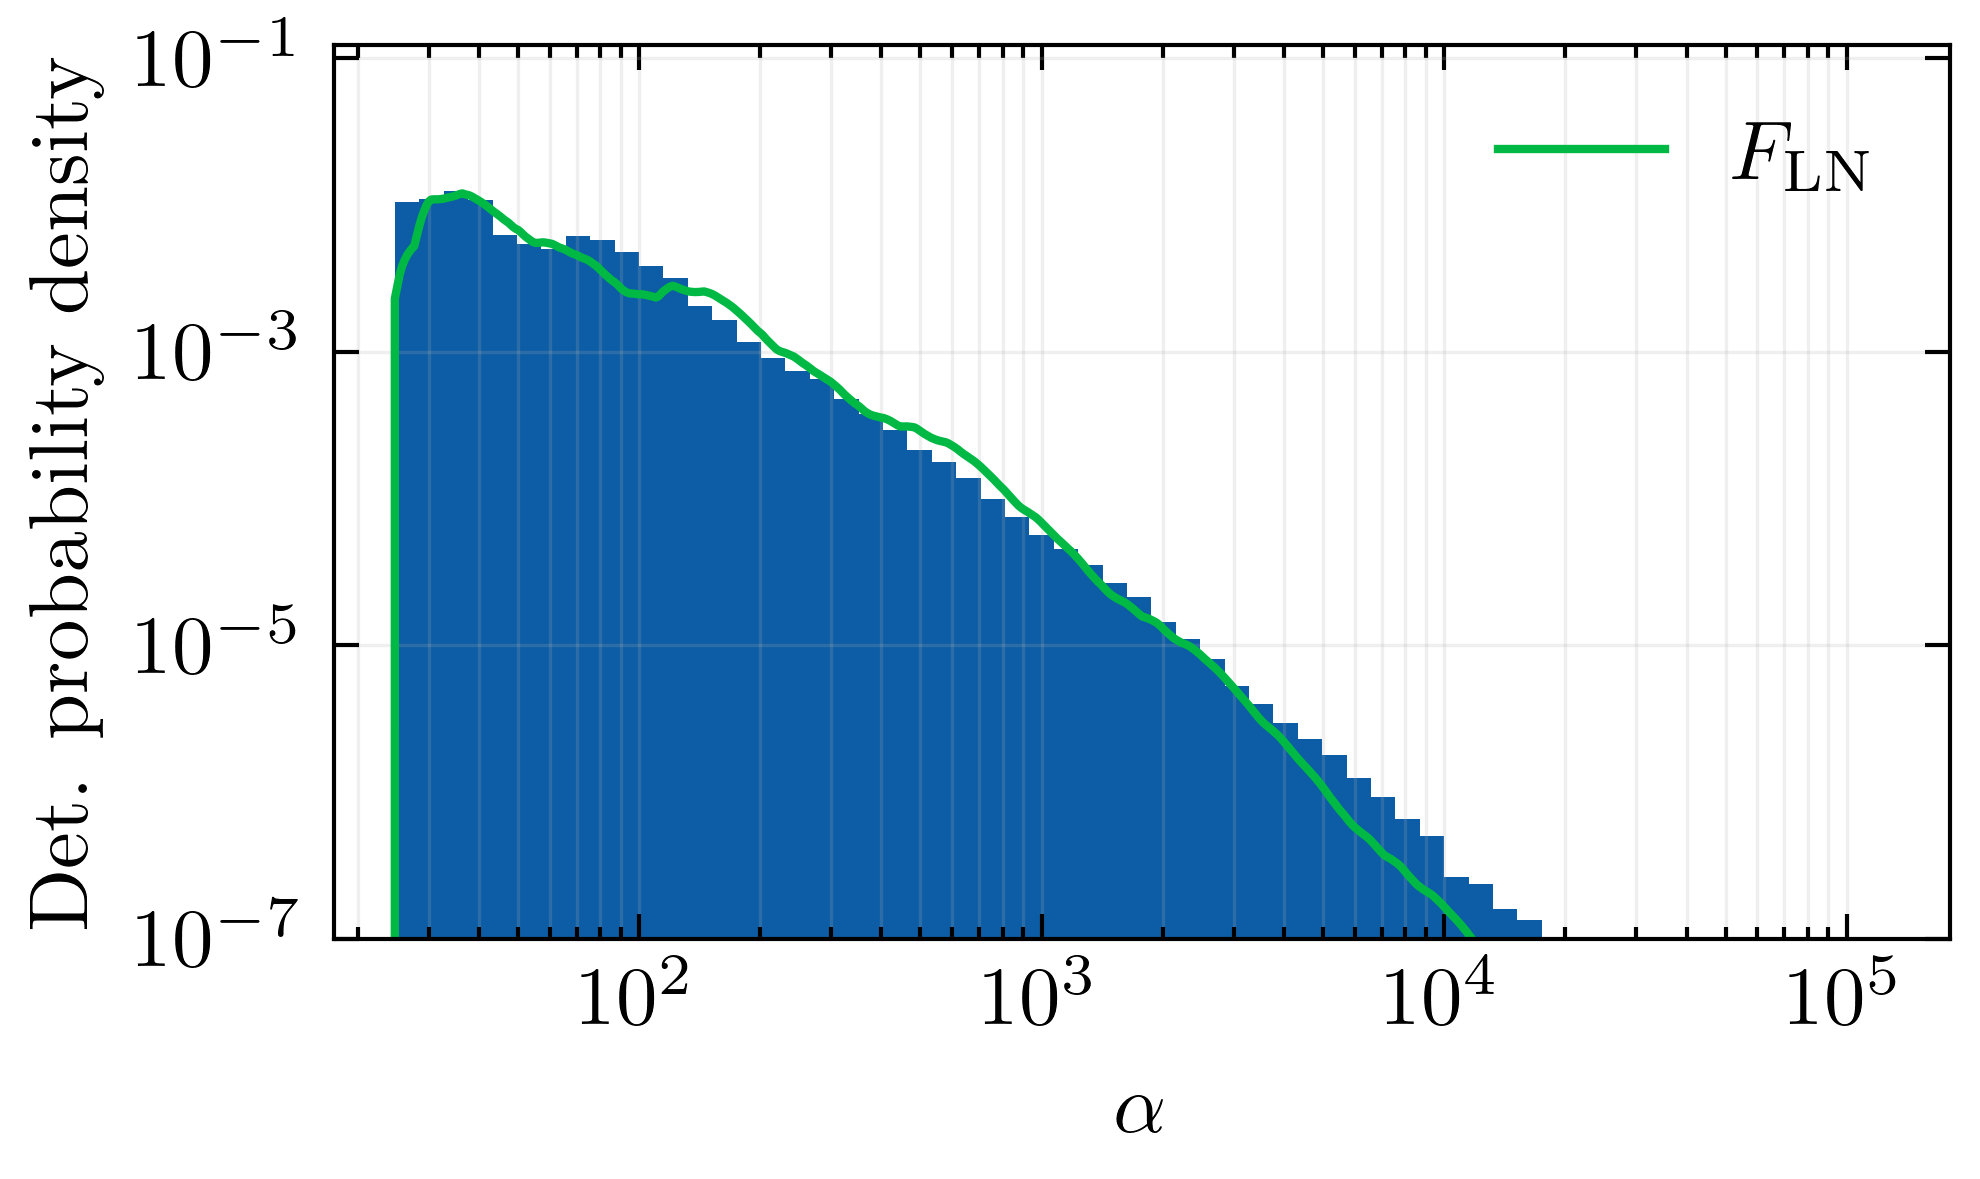

In [6]:
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True)

fit_params = LogNormalFitParams(*mle_model.params)
plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_p_function), label = r"$F_{\text{LN}}$")

plt.ylim(1e-7, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.show()

In [5]:
from datetime import datetime

output_dir = Path("MLE_random_sample_fit_data/LogNormal")

while True:
    df = fit.MultiMLEFit(
        optimize_params=LogNormalFitParams(mu=-2.302585093, sigma=2),
        numb_runs=20,
        summary = False
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"
    filename.parent.mkdir(parents=True, exist_ok=True)

    df.write_parquet(filename)

    print(f"Saved {filename}")

MultiMLE fit running:   0%|          | 0/20 [00:00<?, ?it/s]

Optimization terminated successfully.
         Current function value: 6.256929
         Iterations: 33
         Function evaluations: 64


MultiMLE fit running:   5%|▌         | 1/20 [00:19<06:08, 19.39s/it]


KeyboardInterrupt: 